# AfriShop  Projet 2 : EDA & profiling des données sources

**Formation Data Engineering :  · Plateforme Lakehouse e-commerce panafricain**

Ce notebook réalise la **phase 2 (exploration & profiling)** du projet. Il a trois objectifs :

1. **Connaître les données** : volumétrie, structure, complétude, distributions, clés.
2. **Quantifier les anomalies** annoncées dans le sujet (§10.3) et **détecter celles qui n'y figurent pas**.
3. **Produire des règles de traitement chiffrées** pour la zone *curated* (dédup, quarantaine, réconciliation) et les futures suites Great Expectations / tests dbt.

| Section | Contenu |
|---|---|
| 1 | Configuration |
| 2 | Chargement & inventaire |
| 3 | Profiling par table |
| 4 | Clés primaires & intégrité référentielle |
| 5 | Anomalies documentées dans le sujet (8) |
| 6 | Contrôles de validité et de cohérence complémentaires |
| 7 | EDA métier |



## 1. Configuration

In [1]:
import json
import os
import platform
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})

TABLES = ["orders", "order_lines", "customers", "products", "payments", "deliveries"]
TOL = 0.05  # tolérance monétaire (arrondis) pour les contrôles de montants

def resolve_data_dir() -> Path:
    # Ordre : variable d'environnement AFRISHOP_DATA_DIR, puis emplacements usuels du dépôt.
    candidates = []
    if os.environ.get("AFRISHOP_DATA_DIR"):
        candidates.append(os.environ["AFRISHOP_DATA_DIR"])
    candidates += ["data/raw", "data", "projet data", "../projet data",
                   "projet 2 - Data ecommerce/projet data", "."]
    for c in candidates:
        p = Path(c)
        if all((p / f"{t}.csv").exists() for t in TABLES):
            return p
    raise FileNotFoundError("CSV introuvables. Définir AFRISHOP_DATA_DIR vers le dossier contenant les 6 fichiers.")

DATA_DIR = resolve_data_dir()
REPORT_DIR = Path(os.environ.get("AFRISHOP_REPORT_DIR", "reports/profiling"))
FIG_DIR = REPORT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str) -> None:
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

print(f"Données   : {DATA_DIR}")
print(f"Rapports  : {REPORT_DIR}")
print(f"Python {platform.python_version()} · pandas {pd.__version__} · numpy {np.__version__}")

Données   : data/raw
Rapports  : reports/profiling
Python 3.12.3 · pandas 3.0.2 · numpy 2.4.4


## 2. Chargement & inventaire

Les fichiers sont lus **tels que livrés** (aucune correction). Les timestamps sont normalisés en UTC naïf pour permettre des comparaisons homogènes (`orders` porte un fuseau `+00:00`, les autres tables non).

In [2]:
DATE_COLS = {
    "orders": ["order_date", "created_at", "updated_at"],
    "customers": ["registration_date"],
    "products": ["created_at", "updated_at"],
    "payments": ["payment_date"],
    "deliveries": ["shipped_at", "delivered_at"],
}
EXPECTED_ROWS = {  # volumes annoncés dans le sujet (§10.1)
    "orders": 52_000, "order_lines": 107_517, "customers": 81_200,
    "products": 12_000, "payments": 46_141, "deliveries": 41_218,
}

def parse_dates(df: pd.DataFrame, cols: list) -> tuple:
    df = df.copy()
    failures = {}
    for c in cols:
        before = df[c].notna().sum()
        df[c] = pd.to_datetime(df[c], utc=True, errors="coerce").dt.tz_localize(None)
        failures[c] = int(before - df[c].notna().sum())
    return df, failures

raw = {t: pd.read_csv(DATA_DIR / f"{t}.csv") for t in TABLES}
dfs, parse_failures = {}, {}
for t in TABLES:
    dfs[t], parse_failures[t] = parse_dates(raw[t], DATE_COLS.get(t, []))

orders, lines, customers, products, payments, deliveries = (dfs[t] for t in TABLES)

inventory = pd.DataFrame({
    t: {
        "rows": len(dfs[t]),
        "columns": dfs[t].shape[1],
        "memory_MB": dfs[t].memory_usage(deep=True).sum() / 1e6,
        "rows_brief": EXPECTED_ROWS[t],
    } for t in TABLES
}).T
inventory["delta_vs_brief"] = inventory["rows"] - inventory["rows_brief"]
display(inventory.astype({"rows": int, "columns": int, "rows_brief": int, "delta_vs_brief": int}))

bad_dates = {t: f for t, f in parse_failures.items() if any(f.values())}
print("Échecs de parsing de dates :", bad_dates if bad_dates else "aucun")

,rows,columns,memory_MB,rows_brief,delta_vs_brief
orders,52000,18,36.70,52000,0
order_lines,107517,9,41.57,107517,0
customers,81200,14,57.67,81200,0
products,12000,15,7.25,12000,0
payments,46141,9,21.73,46141,0
deliveries,41218,9,15.84,41218,0


Échecs de parsing de dates : aucun


## 3. Profiling par table

Pour chaque colonne : type, complétude, cardinalité, bornes, valeur dominante. Suivent les statistiques descriptives des colonnes numériques (avec percentiles 1 / 99 pour repérer les extrêmes) et la répartition des colonnes catégorielles à faible cardinalité.

In [3]:
def profile_table(df: pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        non_null = int(s.notna().sum())
        distinct = int(s.nunique(dropna=True))
        is_num = pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s)
        is_dt = pd.api.types.is_datetime64_any_dtype(s)
        vc = s.value_counts(dropna=True)
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "nulls": n - non_null,
            "null_%": 100 * (n - non_null) / n,
            "distinct": distinct,
            "distinct_%": 100 * distinct / n,
            "min": s.min() if (is_num or is_dt) else None,
            "max": s.max() if (is_num or is_dt) else None,
            "top_value": vc.index[0] if len(vc) else None,
            "top_freq_%": 100 * vc.iloc[0] / max(non_null, 1) if len(vc) else None,
        })
    return pd.DataFrame(rows).set_index("column")

PROFILES = {t: profile_table(dfs[t]) for t in TABLES}

def show_table_profile(t: str, cat_max_distinct: int = 12) -> None:
    df = dfs[t]
    display(Markdown(f"### `{t}` — {len(df):,} lignes × {df.shape[1]} colonnes"))
    display(PROFILES[t])
    num = df.select_dtypes("number")
    if not num.empty:
        display(Markdown("**Statistiques numériques**"))
        display(num.describe(percentiles=[.01, .05, .5, .95, .99]).T)
    cats = [c for c in df.columns
            if (df[c].dtype == object or str(df[c].dtype).startswith(("str", "string", "bool")))
            and df[c].nunique() <= cat_max_distinct]
    for c in cats:
        vc = df[c].value_counts(dropna=False)
        display(pd.DataFrame({"count": vc, "%": 100 * vc / len(df)}).rename_axis(c))

show_table_profile("orders")

### `orders` — 52,000 lignes × 18 colonnes

,dtype,nulls,null_%,distinct,distinct_%,min,max,top_value,top_freq_%
column,,,,,,,,,
order_id,str,0,0.00,50500,97.12,None,None,e56db8f5-adb6-405d-9e9b-13072cd2c037,0.01
order_number,str,0,0.00,50500,97.12,None,None,AS-20260131-011107,0.01
customer_id,str,0,0.00,36361,69.92,None,None,CUST-EC-050056463,0.02
order_date,datetime64[us],0,0.00,46811,90.02,2025-05-01 07:03:00,2026-04-30 23:59:00,2026-04-26 15:02:00,0.01
order_status,str,0,0.00,7,0.01,None,None,DELIVERED,59.83
channel,str,0,0.00,5,0.01,None,None,MOBILE_APP,55.38
country_code,str,0,0.00,4,0.01,None,None,SEN,35.00
delivery_address_city,str,0,0.00,27,0.05,None,None,Mbour,5.17
delivery_address_region,str,0,0.00,27,0.05,None,None,Mbour,5.17


**Statistiques numériques**

,count,mean,std,min,1%,5%,50%,95%,99%,max
subtotal_amount,"52,000.00","118,415.22","98,664.82","-1,444.95","2,783.73","10,774.30","90,559.95","315,508.61","439,000.83","788,133.85"
shipping_amount,"52,000.00","2,709.39","1,304.74",500.24,546.20,729.76,"2,677.69","4,673.22","6,126.17","6,498.46"
discount_amount,"52,000.00","4,537.12","8,457.41",-133.34,0.00,0.00,0.00,"23,197.39","36,980.62","78,813.39"
total_amount,"52,000.00","116,635.07","95,066.93",107.41,"5,475.89","13,105.16","89,835.05","307,605.00","428,409.09","758,630.06"


,count,%
order_status,,
DELIVERED,31114,59.83
CANCELLED,6381,12.27
SHIPPED,4142,7.97
RETURNED,3645,7.01
CONFIRMED,3095,5.95
PROCESSING,2060,3.96
PENDING,1563,3.01


,count,%
channel,,
MOBILE_APP,28795,55.38
WEB,12771,24.56
WHATSAPP_BOT,6263,12.04
CALL_CENTER,2585,4.97
AGENT_BIZ,1586,3.05


,count,%
country_code,,
SEN,18200,35.00
NGA,15603,30.01
GHA,10386,19.97
CIV,7811,15.02


,count,%
delivery_address_zone,,
URBAN,31382,60.35
PERI_URBAN,14567,28.01
RURAL,6051,11.64


,count,%
promo_code,,
NaN,32220,61.96
BLACKFRIDAY,4217,8.11
WEEKEND5,4188,8.05
WELCOME10,3646,7.01
RAMADAN15,3605,6.93
TABASKI20,2613,5.03
VIP25,1511,2.91


,count,%
currency,,
XOF,26011,50.02
NGN,15603,30.01
GHS,10386,19.97


In [4]:
show_table_profile("order_lines")

### `order_lines` — 107,517 lignes × 9 colonnes

,dtype,nulls,null_%,distinct,distinct_%,min,max,top_value,top_freq_%
column,,,,,,,,,
order_line_id,str,0,0.00,107517,100.00,NaN,NaN,3de72a50-9ff3-41a9-be7d-b10e6035bb0b,0.00
order_id,str,0,0.00,50000,46.50,NaN,NaN,33470ea5-932b-4b37-a5a3-bbb2f25764e3,0.01
product_id,str,0,0.00,11577,10.77,NaN,NaN,PRD-030000159,0.02
product_sku,str,0,0.00,11382,10.59,NaN,NaN,ÉLE-010159,0.02
quantity,int64,0,0.00,4,0.00,1.00,4.00,1,60.90
unit_price,float64,0,0.00,106735,99.27,434.03,"102,556.44","67,562.18",0.00
line_discount,int64,0,0.00,4,0.00,0.00,"2,000.00",0,85.38
line_total,float64,0,0.00,106969,99.49,"-1,458.27","408,373.08","5,882.32",0.00
seller_id,str,0,0.00,5237,4.87,NaN,NaN,SLR-04906,0.10


**Statistiques numériques**

,count,mean,std,min,1%,5%,50%,95%,99%,max
quantity,"107,517.00",1.59,0.86,1.00,1.00,1.00,1.00,4.00,4.00,4.00
unit_price,"107,517.00","34,780.63","21,961.54",434.03,"1,216.39","3,803.95","32,562.67","75,057.52","87,327.92","102,556.44"
line_discount,"107,517.00",141.42,403.36,0.00,0.00,0.00,0.00,"1,000.00","2,000.00","2,000.00"
line_total,"107,517.00","55,370.55","50,080.58","-1,458.27","1,406.32","4,828.99","42,115.76","158,432.23","243,060.71","408,373.08"


In [5]:
show_table_profile("customers")

### `customers` — 81,200 lignes × 14 colonnes

,dtype,nulls,null_%,distinct,distinct_%,min,max,top_value,top_freq_%
column,,,,,,,,,
customer_id,str,0,0.00,81190,99.99,None,None,CUST-EC-060012446,0.00
email_hash,str,0,0.00,80000,98.52,None,None,ae0b758bfb197a43,0.00
phone_hash,str,0,0.00,80000,98.52,None,None,63e9d48ce27dfa4b,0.00
first_name,str,0,0.00,64,0.08,None,None,Mafoudia,1.66
last_name,str,0,0.00,62,0.08,None,None,Dieng,1.72
birth_year,int64,0,0.00,43,0.05,1965,2007,2003,2.43
gender,str,0,0.00,3,0.00,None,None,F,49.89
registration_date,datetime64[us],0,0.00,1486,1.83,2021-11-23 00:00:00,2025-12-17 00:00:00,2024-01-13 00:00:00,0.10
country_code,str,0,0.00,4,0.00,None,None,SEN,35.21


**Statistiques numériques**

,count,mean,std,min,1%,5%,50%,95%,99%,max
birth_year,"81,200.00","1,985.99",12.40,"1,965.00","1,965.00","1,967.00","1,986.00","2,005.00","2,007.00","2,007.00"


,count,%
gender,,
F,40509,49.89
M,36646,45.13
NOT_DECLARED,4045,4.98


,count,%
country_code,,
SEN,28589,35.21
NGA,24333,29.97
GHA,16132,19.87
CIV,12146,14.96


,count,%
customer_segment,,
REGULAR,48819,60.12
NEW,17789,21.91
DORMANT,8104,9.98
VIP,6488,7.99


,count,%
preferred_payment_method,,
OM_MOBILE_MONEY,22601,27.83
WAVE,17945,22.10
MTN_MOMO,16412,20.21
COD,11972,14.74
CARD,9784,12.05
BANK_TRANSFER,2486,3.06


,count,%
loyalty_tier,,
BRONZE,44472,54.77
SILVER,22846,28.14
GOLD,9823,12.10
PLATINUM,4059,5.00


,count,%
account_status,,
ACTIVE,74650,91.93
SUSPENDED,4043,4.98
CLOSED,2507,3.09


In [6]:
show_table_profile("products")

### `products` — 12,000 lignes × 15 colonnes

,dtype,nulls,null_%,distinct,distinct_%,min,max,top_value,top_freq_%
column,,,,,,,,,
product_id,str,0,0.00,12000,100.00,None,None,PRD-030000000,0.01
sku,str,0,0.00,12000,100.00,None,None,SPO-010000,0.01
product_name,str,0,0.00,2010,16.75,None,None,Smartphone Tecno Spark,0.18
category_id,str,0,0.00,8,0.07,None,None,CAT-004,16.27
category_name,str,0,0.00,8,0.07,None,None,Électronique,16.27
subcategory_name,str,0,0.00,24,0.20,None,None,Accessoires,8.09
brand,str,0,0.00,21,0.17,None,None,Nescafé,5.15
seller_id,str,0,0.00,3812,31.77,None,None,SLR-03814,0.08
unit_cost,float64,0,0.00,11980,99.83,301.70,"97,235.95","32,975.47",0.03


**Statistiques numériques**

,count,mean,std,min,1%,5%,50%,95%,99%,max
unit_cost,"12,000.00","17,869.27","10,212.89",301.70,646.93,"2,114.78","17,894.55","33,441.04","34,719.46","97,235.95"
unit_price,"12,000.00","35,041.70","22,241.58",0.00,455.16,"3,271.82","32,992.87","75,518.57","87,118.41","97,872.60"
weight_grams,"12,000.00","3,994.44","2,296.51",50.00,132.00,441.95,"3,973.50","7,586.05","7,922.01","8,000.00"


,count,%
category_id,,
CAT-004,1952,16.27
CAT-002,1908,15.90
CAT-003,1884,15.70
CAT-006,1443,12.03
CAT-008,1443,12.03
CAT-005,1424,11.87
CAT-007,998,8.32
CAT-001,948,7.90


,count,%
category_name,,
Électronique,1952,16.27
Beauté,1908,15.90
Mode,1884,15.70
Maison,1443,12.03
Alimentation,1443,12.03
Bébé & Enfant,1424,11.87
Téléphonie,998,8.32
Sport,948,7.90


,count,%
is_perishable,,
False,11447,95.39
True,553,4.61


,count,%
product_status,,
ACTIVE,9560,79.67
OUT_OF_STOCK,1492,12.43
DISCONTINUED,948,7.90


In [7]:
show_table_profile("payments")

### `payments` — 46,141 lignes × 9 colonnes

,dtype,nulls,null_%,distinct,distinct_%,min,max,top_value,top_freq_%
column,,,,,,,,,
payment_id,str,0,0.00,46141,100.00,None,None,bb14de9f-ed97-49ac-813a-e307d4b0fc01,0.00
order_id,str,0,0.00,45641,98.92,None,None,77ae5bd4-abff-47bd-bce5-01881712da54,0.01
payment_method,str,0,0.00,6,0.01,None,None,OM_MOBILE_MONEY,27.92
payment_provider,str,0,0.00,6,0.01,None,None,PayDunya,27.92
payment_amount,float64,0,0.00,45590,98.81,107.41,"758,630.06","5,029.28",0.01
currency,str,0,0.00,3,0.01,None,None,XOF,49.99
payment_status,str,0,0.00,5,0.01,None,None,CAPTURED,79.47
payment_date,datetime64[us],0,0.00,42577,92.28,2025-05-01 07:03:00,2026-04-30 23:59:00,2025-12-04 19:42:00,0.01
transaction_reference,str,0,0.00,46132,99.98,None,None,PSP-12022712,0.00


**Statistiques numériques**

,count,mean,std,min,1%,5%,50%,95%,99%,max
payment_amount,"46,141.00","116,219.68","95,125.79",107.41,"5,444.72","13,019.27","89,281.72","307,500.72","429,331.18","758,630.06"


,count,%
payment_method,,
OM_MOBILE_MONEY,12883,27.92
WAVE,10108,21.91
MTN_MOMO,8356,18.11
COD,7840,16.99
CARD,5590,12.12
BANK_TRANSFER,1364,2.96


,count,%
payment_provider,,
PayDunya,12883,27.92
Wave Direct,10108,21.91
Flutterwave,8356,18.11
Internal,7840,16.99
Paystack,5590,12.12
CinetPay,1364,2.96


,count,%
currency,,
XOF,23066,49.99
NGN,13865,30.05
GHS,9210,19.96


,count,%
payment_status,,
CAPTURED,36669,79.47
FAILED,4004,8.68
PENDING,2272,4.92
REFUNDED,2263,4.90
AUTHORIZED,933,2.02


In [8]:
show_table_profile("deliveries")

### `deliveries` — 41,218 lignes × 9 colonnes

,dtype,nulls,null_%,distinct,distinct_%,min,max,top_value,top_freq_%
column,,,,,,,,,
delivery_id,str,0,0.00,41218,100.00,None,None,42c5ae54-d78a-486f-9662-42b8c3dc93ca,0.00
order_id,str,0,0.00,41218,100.00,None,None,ee1e6eda-3997-4474-bdbf-841206a894de,0.00
carrier,str,0,0.00,8,0.02,None,None,YANGO_DELIVERY,12.68
tracking_number,str,0,0.00,41218,100.00,None,None,TRK-5192499498,0.00
delivery_status,str,0,0.00,6,0.01,None,None,DELIVERED,71.73
shipped_at,datetime64[us],0,0.00,38870,94.30,2025-05-02 07:51:00,2026-05-03 22:46:00,2026-01-26 16:06:00,0.01
delivered_at,datetime64[us],11651,28.27,28409,68.92,2025-05-03 07:12:00,2026-05-20 22:46:00,2025-09-02 09:56:00,0.01
delivery_attempts,int64,0,0.00,3,0.01,1,3,1,75.24
delivery_cost,float64,0,0.00,39454,95.72,800.09,"5,499.97","3,070.44",0.01


**Statistiques numériques**

,count,mean,std,min,1%,5%,50%,95%,99%,max
delivery_attempts,"41,218.00",1.32,0.60,1.00,1.00,1.00,1.00,3.00,3.00,3.00
delivery_cost,"41,218.00","3,150.37","1,356.11",800.09,847.89,"1,040.30","3,151.73","5,267.99","5,452.14","5,499.97"


,count,%
carrier,,
YANGO_DELIVERY,5227,12.68
BOLT_DELIVERY,5199,12.61
GLOVO,5176,12.56
CHRONOPOST_AFRIQUE,5168,12.54
DHL,5162,12.52
INTERNAL_FLEET,5138,12.47
AFRIPOST,5124,12.43
JUMIA_LOGISTICS,5024,12.19


,count,%
delivery_status,,
DELIVERED,29567,71.73
IN_TRANSIT,3421,8.30
RETURNED_TO_WAREHOUSE,2500,6.07
FAILED,2073,5.03
OUT_FOR_DELIVERY,2052,4.98
PREPARING,1605,3.89


## 4. Clés primaires & intégrité référentielle

### 4.1 Unicité des clés primaires

In [9]:
PRIMARY_KEYS = {
    "orders": "order_id", "order_lines": "order_line_id", "customers": "customer_id",
    "products": "product_id", "payments": "payment_id", "deliveries": "delivery_id",
}
pk_rows = []
for t, pk in PRIMARY_KEYS.items():
    df = dfs[t]
    pk_rows.append({
        "table": t, "pk": pk, "rows": len(df), "distinct_keys": df[pk].nunique(),
        "null_keys": int(df[pk].isna().sum()),
        "rows_with_repeated_key": int(df[pk].duplicated(keep=False).sum()),
        "surplus_rows": int(df[pk].duplicated().sum()),
        "fully_identical_rows": int(df.duplicated().sum()),
    })
pk_report = pd.DataFrame(pk_rows).set_index("table")
display(pk_report)

,pk,rows,distinct_keys,null_keys,rows_with_repeated_key,surplus_rows,fully_identical_rows
table,,,,,,,
orders,order_id,52000,50500,0,2973,1500,1500
order_lines,order_line_id,107517,107517,0,0,0,0
customers,customer_id,81200,81190,0,20,10,0
products,product_id,12000,12000,0,0,0,0
payments,payment_id,46141,46141,0,0,0,0
deliveries,delivery_id,41218,41218,0,0,0,0


### 4.2 Intégrité référentielle (enfant → parent) et couverture inverse

In [10]:
FOREIGN_KEYS = [
    ("order_lines", "order_id", "orders", "order_id"),
    ("order_lines", "product_id", "products", "product_id"),
    ("orders", "customer_id", "customers", "customer_id"),
    ("payments", "order_id", "orders", "order_id"),
    ("deliveries", "order_id", "orders", "order_id"),
]
fk_rows = []
for child, fk, parent, pk in FOREIGN_KEYS:
    valid = dfs[parent][pk].dropna().unique()
    orphan = ~dfs[child][fk].isin(valid)
    fk_rows.append({
        "child": child, "fk": fk, "parent": parent,
        "orphan_rows": int(orphan.sum()),
        "orphan_%": 100 * orphan.mean(),
        "orphan_distinct_keys": dfs[child].loc[orphan, fk].nunique(),
    })
fk_report = pd.DataFrame(fk_rows)
display(fk_report)

cov_rows = []
order_ids = orders["order_id"].drop_duplicates()
for child in ["order_lines", "payments", "deliveries"]:
    missing = ~order_ids.isin(dfs[child]["order_id"])
    cov_rows.append({"parent → child": f"orders → {child}", "orders_without_child": int(missing.sum()),
                     "%_of_distinct_orders": 100 * missing.mean()})
display(pd.DataFrame(cov_rows))

,child,fk,parent,orphan_rows,orphan_%,orphan_distinct_keys
0,order_lines,order_id,orders,0,0.00,0
1,order_lines,product_id,products,2108,1.96,2105
2,orders,customer_id,customers,0,0.00,0
3,payments,order_id,orders,0,0.00,0
4,deliveries,order_id,orders,0,0.00,0


,parent → child,orders_without_child,%_of_distinct_orders
0,orders → order_lines,500,0.99
1,orders → payments,4859,9.62
2,orders → deliveries,9282,18.38


## 5. Anomalies documentées dans le sujet (§10.3)

Chaque anomalie est **quantifiée**, comparée au taux annoncé, puis **enregistrée** dans un registre unique (`ANOMALIES`) exporté en section 9. La colonne *traitement* est une proposition de règle pour la zone curated.

In [11]:
ANOMALIES = []

def register(code, table, description, observed, base, brief, severity, treatment):
    ANOMALIES.append({
        "code": code, "table": table, "description": description,
        "observed": int(observed), "base": int(base),
        "observed_%": round(100 * observed / base, 2) if base else np.nan,
        "brief_expected": brief, "severity": severity, "treatment": treatment,
    })

### A1 — Doublons techniques sur `orders`

In [12]:
dup_mask = orders.duplicated("order_id", keep="first")
identical_mask = orders.duplicated(keep="first")
n_dup = int(dup_mask.sum())
n_conflict = int((dup_mask & ~identical_mask).sum())

print(f"Lignes en surplus (même order_id) : {n_dup:,} ({100*n_dup/len(orders):.2f} % des lignes)")
print(f"  dont doublons strictement identiques : {int(identical_mask.sum()):,}")
print(f"  dont doublons avec valeurs divergentes (conflit) : {n_conflict:,}")
print(f"Commandes distinctes après déduplication : {orders['order_id'].nunique():,}")

# Jeu dédoublonné de référence pour toute la suite (on garde la version la plus récente)
orders_u = (orders.sort_values(["order_id", "updated_at"])
                  .drop_duplicates("order_id", keep="last")
                  .reset_index(drop=True))

register("A1", "orders", "order_id dupliqué (doublon technique)", n_dup, len(orders),
         "~3 % (~1 500)", "Haute",
         "Dédup sur order_id (garder updated_at max) ; conserver l'écart en table d'audit")

Lignes en surplus (même order_id) : 1,500 (2.88 % des lignes)
  dont doublons strictement identiques : 1,500
  dont doublons avec valeurs divergentes (conflit) : 0
Commandes distinctes après déduplication : 50,500


### A2 — Lignes de commande référençant un `product_id` inexistant

In [13]:
orphan_line = ~lines["product_id"].isin(products["product_id"])
expected_lt = lines["quantity"] * lines["unit_price"] - lines["line_discount"]
lt_mismatch = (expected_lt - lines["line_total"]).abs() > TOL

n_orphan = int(orphan_line.sum())
print(f"Lignes orphelines : {n_orphan:,} ({100*n_orphan/len(lines):.2f} %) — {lines.loc[orphan_line,'order_id'].nunique():,} commandes touchées")
print("\nSignature des orphelines (préfixe SKU / préfixe product_id) :")
display(pd.DataFrame({
    "sku_prefix": lines.loc[orphan_line, "product_sku"].str.split("-").str[0].value_counts(),
}))
display(pd.crosstab(orphan_line.rename("orpheline"), lt_mismatch.rename("line_total_incoherent"), margins=True))

# Dérive de prix : le prix de la ligne peut légitimement différer du prix courant du catalogue
m = lines.loc[~orphan_line].merge(products[["product_id", "unit_price", "sku"]], on="product_id", suffixes=("", "_cat"))
ratio = m["unit_price"] / m["unit_price_cat"].replace(0, np.nan)
print(f"\nLignes valides : ratio unit_price(ligne) / prix catalogue courant → min {ratio.min():.3f} · médiane {ratio.median():.3f} · max {ratio.max():.3f}")
print(f"  lignes au prix catalogue exact : {int(((m['unit_price'] - m['unit_price_cat']).abs() <= 0.01).sum()):,} → le prix de ligne est un prix historique borné autour du prix courant : à conserver tel quel (ne pas recalculer depuis le catalogue)")
print(f"Lignes valides dont product_sku ≠ sku catalogue courant : {int((m['product_sku']!=m['sku']).sum()):,}")

register("A2", "order_lines", "product_id absent de products (intégrité référentielle)", n_orphan, len(lines),
         "~2 % (~2 100)", "Haute",
         "Quarantaine des lignes orphelines ; exclure de FACT_ORDER_LINE ; alerte si taux > seuil")
register("A2b", "order_lines", "line_total ≠ quantity × unit_price − line_discount", int(lt_mismatch.sum()), len(lines),
         "non documenté", "Haute",
         "Quarantaine (ici entièrement corrélé aux lignes orphelines) ; test dbt sur la formule")

Lignes orphelines : 2,108 (1.96 %) — 2,070 commandes touchées

Signature des orphelines (préfixe SKU / préfixe product_id) :


,sku_prefix
product_sku,
GHOST,2108


line_total_incoherent,False,True,All
orpheline,,,
False,105409,0,105409
True,0,2108,2108
All,105409,2108,107517



Lignes valides : ratio unit_price(ligne) / prix catalogue courant → min 0.950 · médiane 1.000 · max 1.050
  lignes au prix catalogue exact : 5 → le prix de ligne est un prix historique borné autour du prix courant : à conserver tel quel (ne pas recalculer depuis le catalogue)
Lignes valides dont product_sku ≠ sku catalogue courant : 0


### A3 — Totaux de commande incohérents (validation croisée)

In [14]:
agg = lines.assign(valid_line=~orphan_line).groupby("order_id").agg(
    n_lines=("order_line_id", "count"),
    sum_lines=("line_total", "sum"),
)
agg["sum_valid_lines"] = lines.loc[~orphan_line].groupby("order_id")["line_total"].sum()
agg["n_orphan_lines"] = lines.loc[orphan_line].groupby("order_id").size()
agg["n_orphan_lines"] = agg["n_orphan_lines"].fillna(0).astype(int)

chk = orders_u.merge(agg, on="order_id", how="left")
chk["calc_total"] = chk["subtotal_amount"] + chk["shipping_amount"] - chk["discount_amount"]
chk["gap_total"] = chk["total_amount"] - chk["calc_total"]

f_formula = chk["gap_total"].abs() > TOL                         # total ≠ subtotal + shipping − discount
f_nolines = chk["n_lines"].isna()                                # commande sans aucune ligne
f_subtotal = chk["n_lines"].notna() & ((chk["subtotal_amount"] - chk["sum_lines"]).abs() > TOL)
f_subtotal_valid = chk["n_lines"].notna() & ((chk["subtotal_amount"] - chk["sum_valid_lines"].fillna(0)).abs() > TOL)

summary = pd.DataFrame({
    "commandes": [int(f_formula.sum()), int(f_nolines.sum()), int(f_subtotal.sum()), int(f_subtotal_valid.sum())],
}, index=[
    "total_amount ≠ subtotal + shipping − discount",
    "commande sans ligne de détail",
    "subtotal ≠ Σ line_total (toutes lignes)",
    "subtotal ≠ Σ line_total (lignes valides seulement)",
])
summary["%_commandes"] = 100 * summary["commandes"] / len(chk)
display(summary)

print("Recoupement formule ⇄ commande sans ligne :")
display(pd.crosstab(f_formula.rename("total_incoherent"), f_nolines.rename("sans_ligne"), margins=True))
print("Ampleur de l'écart (total facturé / total recalculé) sur les commandes à total incohérent :")
display((chk.loc[f_formula, "total_amount"] / chk.loc[f_formula, "calc_total"]).describe())

register("A3", "orders", "total_amount ≠ subtotal + shipping − discount", int(f_formula.sum()), len(chk),
         "~1 % (~500)", "Haute",
         "Quarantaine ; recalcul depuis order_lines seulement si lignes disponibles")
register("A3b", "orders", "commande sans aucune ligne de détail", int(f_nolines.sum()), len(chk),
         "non documenté", "Haute",
         "Quarantaine (commande non exploitable en FACT_ORDER_LINE)")
register("A3c", "orders", "subtotal ≠ Σ line_total (impact des lignes orphelines)", int(f_subtotal.sum()), len(chk),
         "non documenté", "Moyenne",
         "Réconcilier après retrait des lignes orphelines ; test dbt de réconciliation")

,commandes,%_commandes
total_amount ≠ subtotal + shipping − discount,500,0.99
commande sans ligne de détail,500,0.99
subtotal ≠ Σ line_total (toutes lignes),2070,4.10
subtotal ≠ Σ line_total (lignes valides seulement),0,0.00


Recoupement formule ⇄ commande sans ligne :


sans_ligne,False,True,All
total_incoherent,,,
False,50000,0,50000
True,0,500,500
All,50000,500,50500


Ampleur de l'écart (total facturé / total recalculé) sur les commandes à total incohérent :


count   500.00
mean      1.11
std       0.20
min       1.01
25%       1.03
50%       1.05
75%       1.11
max       3.84
dtype: float64

### A4 — Paiements : partiels, retries, doubles captures

In [15]:
pay = payments.copy()
per_order = pay.groupby("order_id").agg(
    n_payments=("payment_id", "count"),
    n_failed=("payment_status", lambda s: (s == "FAILED").sum()),
    n_captured=("payment_status", lambda s: (s == "CAPTURED").sum()),
    captured_amount=("payment_amount", lambda s: 0.0),  # remplacé juste après
)
cap = pay[pay["payment_status"] == "CAPTURED"].groupby("order_id")["payment_amount"].sum()
per_order["captured_amount"] = cap
per_order["captured_amount"] = per_order["captured_amount"].fillna(0.0)
pchk = orders_u[["order_id", "total_amount", "order_status", "currency"]].merge(per_order, on="order_id", how="left")
pchk[["n_payments", "n_failed", "n_captured"]] = pchk[["n_payments", "n_failed", "n_captured"]].fillna(0).astype(int)
pchk["ratio"] = np.where(pchk["total_amount"] > 0, pchk["captured_amount"] / pchk["total_amount"], np.nan)

has_capture = pchk["n_captured"] > 0
retry = (pchk["n_failed"] > 0) & has_capture
partial = has_capture & (pchk["ratio"] < 1 - 0.001)
overcap = has_capture & (pchk["ratio"] > 1 + 0.001)
multi_cap = pchk["n_captured"] > 1

print(f"Commandes avec ≥ 1 paiement : {int((pchk['n_payments']>0).sum()):,} / {len(pchk):,}")
print(f"Commandes avec ≥ 2 paiements : {int((pchk['n_payments']>1).sum()):,}")
display(pd.Series({
    "retry FAILED → CAPTURED": int(retry.sum()),
    "encaissement partiel (Σ CAPTURED < total)": int(partial.sum()),
    "sur-encaissement (Σ CAPTURED > total)": int(overcap.sum()),
    "commandes avec > 1 paiement CAPTURED": int(multi_cap.sum()),
}, name="commandes"))

print("Distribution du ratio encaissé / total (commandes avec capture, ratio ≠ 1) :")
display(pchk.loc[has_capture & ((pchk['ratio'] - 1).abs() > 0.001), "ratio"].round(2).value_counts().head(10).rename_axis("ratio").to_frame("commandes"))
print("Séquences de statuts par commande (ordre chronologique), top 8 :")
seq = pay.sort_values(["order_id", "payment_date"]).groupby("order_id")["payment_status"].apply(lambda s: " → ".join(s))
display(seq[seq.str.contains("→")].value_counts().head(8).rename_axis("séquence").to_frame("commandes"))

register("A4a", "payments", "retry FAILED → CAPTURED (commande à ≥ 1 échec puis capture)", int(retry.sum()), int(has_capture.sum()),
         "~500 commandes", "Moyenne",
         "Dédup : 1 paiement de référence par commande (dernier CAPTURED) ; conserver l'historique en table de tentatives")
register("A4b", "payments", "paiement partiel (Σ CAPTURED < total commande)", int(partial.sum()), int(has_capture.sum()),
         "~1 % (~460)", "Moyenne",
         "Flag is_partial_payment + montant restant dû dans la dimension/fait paiement")
register("A4c", "payments", "sur-encaissement / double capture (Σ CAPTURED > total)", int(overcap.sum()), int(has_capture.sum()),
         "non documenté", "Haute",
         "Quarantaine + rapprochement PSP (transaction_reference) ; ne jamais sommer sans dédup")

Commandes avec ≥ 1 paiement : 45,641 / 50,500
Commandes avec ≥ 2 paiements : 390


retry FAILED → CAPTURED                      390
encaissement partiel (Σ CAPTURED < total)    320
sur-encaissement (Σ CAPTURED > total)         98
commandes avec > 1 paiement CAPTURED          98
Name: commandes, dtype: int64

Distribution du ratio encaissé / total (commandes avec capture, ratio ≠ 1) :


,commandes
ratio,
2.00,85
0.52,15
0.79,14
0.76,12
0.55,12
0.59,11
0.41,10
0.72,10
3.00,10


Séquences de statuts par commande (ordre chronologique), top 8 :


,commandes
séquence,
FAILED → CAPTURED,292
FAILED → CAPTURED → CAPTURED,86
FAILED → CAPTURED → CAPTURED → CAPTURED,12


### A5 — Livraisons tardives et incohérences temporelles

,count,mean,std,min,50%,90%,95%,99%,max
days_order_to_ship,"29,567.00",2.00,0.82,1.00,2.00,3.00,3.00,3.00,3.00
days_ship_to_delivery,"29,567.00",2.49,2.84,-1.00,2.00,5.00,5.00,16.00,20.00
days_order_to_delivery,"29,567.00",4.48,2.72,2.00,4.00,6.00,6.00,18.00,21.00


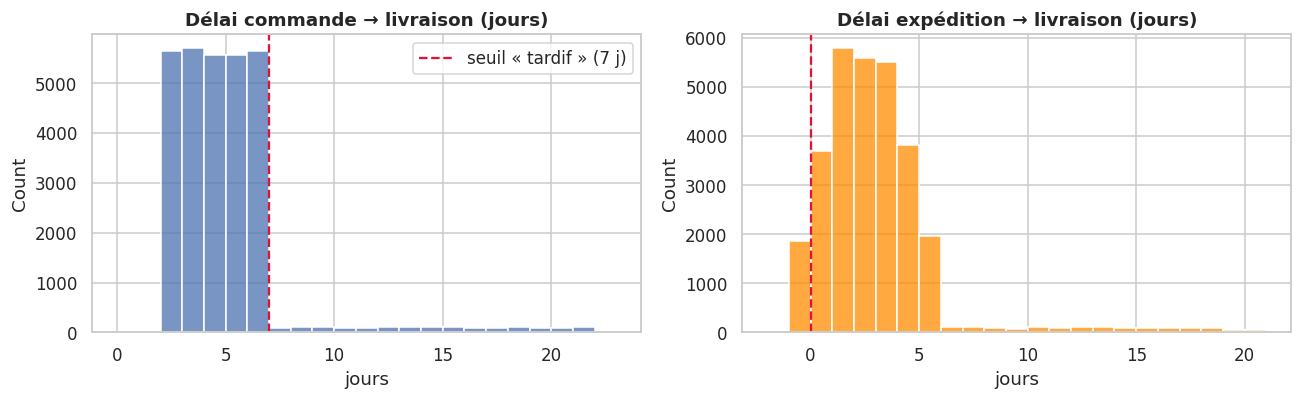

Livraisons effectives : 29,567
Livraisons tardives (≥ 7 j après commande) : 1,451 = 4.91 % des livraisons effectives
Livraisons datées AVANT l'expédition : 1,860 (6.29 %)


In [16]:
dl = deliveries.merge(orders_u[["order_id", "order_date", "delivery_address_zone", "country_code", "order_status"]], on="order_id", how="left")
dl["days_order_to_delivery"] = (dl["delivered_at"] - dl["order_date"]).dt.total_seconds() / 86400
dl["days_order_to_ship"] = (dl["shipped_at"] - dl["order_date"]).dt.total_seconds() / 86400
dl["days_ship_to_delivery"] = (dl["delivered_at"] - dl["shipped_at"]).dt.total_seconds() / 86400

done = dl["days_order_to_delivery"].notna()
late = dl["days_order_to_delivery"] >= 7
display(dl.loc[done, ["days_order_to_ship", "days_ship_to_delivery", "days_order_to_delivery"]].describe(percentiles=[.5, .9, .95, .99]).T)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
sns.histplot(dl.loc[done, "days_order_to_delivery"], bins=range(0, 24), ax=ax[0])
ax[0].axvline(7, color="crimson", ls="--", label="seuil « tardif » (7 j)")
ax[0].set(title="Délai commande → livraison (jours)", xlabel="jours"); ax[0].legend()
sns.histplot(dl.loc[done, "days_ship_to_delivery"], bins=np.arange(-2, 22), ax=ax[1], color="darkorange")
ax[1].axvline(0, color="crimson", ls="--")
ax[1].set(title="Délai expédition → livraison (jours)", xlabel="jours")
savefig("a5_delais_livraison")

neg_transit = dl["days_ship_to_delivery"] < 0
print(f"Livraisons effectives : {int(done.sum()):,}")
print(f"Livraisons tardives (≥ 7 j après commande) : {int(late.sum()):,} = {100*late.sum()/done.sum():.2f} % des livraisons effectives")
print(f"Livraisons datées AVANT l'expédition : {int(neg_transit.sum()):,} ({100*neg_transit.sum()/done.sum():.2f} %)")

register("A5", "deliveries", "livraison tardive (delivered_at ≥ order_date + 7 j)", int(late.sum()), int(done.sum()),
         "~5 % (7 à 21 j)", "Info",
         "Non bloquant : conserver ; réconcilier via late-arriving (MERGE sur order_id) et exposer delay_days")
register("A5b", "deliveries", "delivered_at < shipped_at (incohérence temporelle)", int(neg_transit.sum()), int(done.sum()),
         "non documenté", "Moyenne",
         "Quarantaine ou correction documentée (delay = NULL) ; règle GX delivered_at >= shipped_at")

### A6 — Produits : prix nul et coût supérieur au prix

In [17]:
p0 = products["unit_price"] == 0
neg_margin = products["unit_cost"] > products["unit_price"]
print(f"unit_price = 0            : {int(p0.sum()):,}")
print(f"unit_cost > unit_price    : {int(neg_margin.sum()):,}  (dont prix nul : {int((p0 & neg_margin).sum()):,} ; prix > 0 : {int((neg_margin & ~p0).sum()):,})")
print(f"unit_cost = 0             : {int((products['unit_cost'] == 0).sum()):,}")
print("\nRépartition par catégorie et statut des produits problématiques :")
bad_prod = products[p0 | neg_margin]
display(pd.crosstab(bad_prod["category_name"], bad_prod["product_status"], margins=True))

used = lines["product_id"].isin(bad_prod["product_id"])
print(f"Lignes de commande liées à ces produits : {int(used.sum()):,} ({100*used.mean():.2f} % des lignes)")

register("A6a", "products", "unit_price = 0", int(p0.sum()), len(products),
         "~120", "Moyenne", "Quarantaine du produit ; ne pas utiliser pour valoriser un catalogue")
register("A6b", "products", "unit_cost > unit_price avec prix > 0 (marge négative)", int((neg_margin & ~p0).sum()), len(products),
         "~60", "Moyenne", "Quarantaine / signalement métier ; conserver si vente réelle")

unit_price = 0            : 119
unit_cost > unit_price    : 179  (dont prix nul : 119 ; prix > 0 : 60)
unit_cost = 0             : 0

Répartition par catégorie et statut des produits problématiques :


product_status,ACTIVE,DISCONTINUED,OUT_OF_STOCK,All
category_name,,,,
Alimentation,16,1,1,18
Beauté,28,2,2,32
Bébé & Enfant,12,1,3,16
Maison,16,4,5,25
Mode,23,3,4,30
Sport,19,4,2,25
Téléphonie,7,3,1,11
Électronique,17,2,3,22
All,138,20,21,179


Lignes de commande liées à ces produits : 532 (0.49 % des lignes)


### A7 — Clients : doublons d'`email_hash` (Master Data Management) et collisions de `customer_id`

In [18]:
dup_email = customers["email_hash"].duplicated(keep=False)
grp = customers[dup_email].groupby("email_hash")
group_sizes = grp["customer_id"].nunique()
same_profile_cols = ["phone_hash", "first_name", "last_name", "birth_year", "registration_date", "country_code", "city"]
identical_profile = grp[same_profile_cols].nunique().max(axis=1) == 1

surplus_email = int(customers["email_hash"].duplicated().sum())
print(f"Comptes en surplus (même email_hash) : {surplus_email:,} ({100*surplus_email/len(customers):.2f} %)")
print(f"Groupes de doublons : {len(group_sizes):,} · taille des groupes : {group_sizes.value_counts().to_dict()}")
print(f"Groupes dont tous les attributs d'identité sont identiques : {int(identical_profile.sum()):,} / {len(group_sizes):,}")
print(f"Doublons de phone_hash : {int(customers['phone_hash'].duplicated().sum()):,}")

# Empreinte des identifiants : les comptes « doublons » ont-ils un préfixe d'ID distinct ?
print("\nPréfixe de customer_id — global vs comptes en surplus :")
pref = customers["customer_id"].str[:11]
surplus_rows = customers["email_hash"].duplicated(keep="first")
display(pd.DataFrame({"tous": pref.value_counts(), "surplus_email": pref[surplus_rows].value_counts()}).fillna(0).astype(int))

# Impact sur les commandes : historique éclaté entre deux identifiants ?
has_orders = customers["customer_id"].isin(orders_u["customer_id"])
g_orders = customers[dup_email].assign(has_orders=has_orders[dup_email]).groupby("email_hash")["has_orders"].sum()
print(f"\nGroupes de doublons dont ≥ 2 identifiants portent des commandes (historique éclaté) : {int((g_orders >= 2).sum()):,}")
print(f"Clients sans aucune commande : {int((~has_orders).sum()):,} ({100*(~has_orders).mean():.1f} %)")

# Collision de customer_id : même identifiant, personnes différentes
dup_id = customers["customer_id"].duplicated(keep=False)
print(f"\nCollisions de customer_id : {int(customers['customer_id'].duplicated().sum()):,} ligne(s) en surplus sur {customers.loc[dup_id,'customer_id'].nunique():,} identifiant(s)")
if dup_id.any():
    display(customers[dup_id].sort_values("customer_id")[["customer_id", "email_hash", "first_name", "last_name", "birth_year", "country_code", "city"]])

register("A7a", "customers", "email_hash dupliqué (compte créé en double)", surplus_email, len(customers),
         "~1 200", "Haute",
         "Clé de rapprochement MDM (email_hash) → customer_master_id ; consolider RFM au niveau master")
register("A7b", "customers", "customer_id dupliqué avec profils différents (collision de clé)", int(customers['customer_id'].duplicated().sum()), len(customers),
         "non documenté", "Haute",
         "Quarantaine ; clé de substitution surrogate_key dans DIM_CUSTOMER ; alerte à l'ingestion")

Comptes en surplus (même email_hash) : 1,200 (1.48 %)
Groupes de doublons : 1,191 · taille des groupes : {2: 1183, 3: 7, 4: 1}
Groupes dont tous les attributs d'identité sont identiques : 1,191 / 1,191
Doublons de phone_hash : 1,200

Préfixe de customer_id — global vs comptes en surplus :


,tous,surplus_email
customer_id,,
CUST-EC-050,80000,0
CUST-EC-060,1200,1200



Groupes de doublons dont ≥ 2 identifiants portent des commandes (historique éclaté) : 277
Clients sans aucune commande : 44,832 (55.2 %)

Collisions de customer_id : 10 ligne(s) en surplus sur 10 identifiant(s)


,customer_id,email_hash,first_name,last_name,birth_year,country_code,city
80024,CUST-EC-060012446,9bb53136c230c0eb,Boubacar,Compaoré,2000,SEN,Saint-Louis
80976,CUST-EC-060012446,f7b460b4a9d20d68,Sékou,Sow,1988,GHA,Takoradi
80852,CUST-EC-060027241,45f02879f6f0540d,Salif,Conté,1991,CIV,San-Pédro
80718,CUST-EC-060027241,70a54ad851fae9be,Idrissa,Sylla,1985,NGA,Benin City
80179,CUST-EC-060036425,88f946193e583cb3,Yaya,Mboup,1985,GHA,Cape Coast
81056,CUST-EC-060036425,523281a2c6dfb702,Abdoulaye,Keita,1968,NGA,Lagos
80476,CUST-EC-060042398,3fd6c4267b4c83f4,Mariétou,Cissé,1980,CIV,Abidjan
80532,CUST-EC-060042398,bc99afd8da3248ed,Ndèye,Mané,2005,SEN,Thiès
80155,CUST-EC-060044581,b5febf41370f345c,Ousmane,Keita,1988,NGA,Benin City
81016,CUST-EC-060044581,9186e6f6c7a57d2b,Bocar,Yansané,1979,NGA,Ibadan


## 6. Contrôles de validité et de cohérence complémentaires

Contrôles **au-delà de la liste du sujet** : domaines de valeurs, bornes, chronologie, cohérence inter-tables, format des hash. Le résultat alimente directement les règles Great Expectations et les tests dbt.

In [19]:
VALIDITY = []

def check(name, table, mask, note=""):
    mask = pd.Series(mask)
    VALIDITY.append({"check": name, "table": table, "violations": int(mask.sum()),
                     "population": int(len(mask)), "violations_%": round(100 * mask.mean(), 3), "note": note})

# --- Domaines de valeurs (sujet §10.2)
ENUMS = {
    ("orders", "order_status"): {"PENDING", "CONFIRMED", "PROCESSING", "SHIPPED", "DELIVERED", "CANCELLED", "RETURNED"},
    ("orders", "channel"): {"WEB", "MOBILE_APP", "WHATSAPP_BOT", "CALL_CENTER", "AGENT_BIZ"},
    ("orders", "country_code"): {"SEN", "GHA", "NGA", "CIV"},
    ("orders", "delivery_address_zone"): {"URBAN", "PERI_URBAN", "RURAL"},
    ("orders", "currency"): {"XOF", "GHS", "NGN"},
    ("customers", "gender"): {"M", "F", "OTHER", "NOT_DECLARED"},
    ("customers", "customer_segment"): {"VIP", "REGULAR", "NEW", "DORMANT"},
    ("customers", "loyalty_tier"): {"BRONZE", "SILVER", "GOLD", "PLATINUM"},
    ("customers", "account_status"): {"ACTIVE", "SUSPENDED", "CLOSED"},
    ("customers", "country_code"): {"SEN", "GHA", "NGA", "CIV"},
    ("products", "product_status"): {"ACTIVE", "OUT_OF_STOCK", "DISCONTINUED"},
    ("products", "category_name"): {"Mode", "Électronique", "Maison", "Beauté", "Alimentation", "Bébé & Enfant", "Sport", "Téléphonie"},
    ("payments", "payment_method"): {"OM_MOBILE_MONEY", "WAVE", "MTN_MOMO", "CARD", "COD", "BANK_TRANSFER"},
    ("payments", "payment_status"): {"PENDING", "AUTHORIZED", "CAPTURED", "FAILED", "REFUNDED"},
    ("payments", "currency"): {"XOF", "GHS", "NGN"},
    ("deliveries", "delivery_status"): {"PREPARING", "IN_TRANSIT", "OUT_FOR_DELIVERY", "DELIVERED", "FAILED", "RETURNED_TO_WAREHOUSE"},
}
for (t, c), allowed in ENUMS.items():
    s = dfs[t][c]
    unexpected = sorted(set(s.dropna()) - allowed)
    check(f"{c} hors domaine autorisé", t, ~s.isin(allowed) & s.notna(), ("valeurs inattendues : " + str(unexpected)[:80]) if unexpected else "")

# --- Valeurs numériques
check("quantity <= 0", "order_lines", lines["quantity"] <= 0)
check("unit_price <= 0", "order_lines", lines["unit_price"] <= 0)
check("line_discount < 0 ou > montant brut", "order_lines", (lines["line_discount"] < 0) | (lines["line_discount"] > lines["quantity"] * lines["unit_price"] + TOL))
check("montants négatifs (subtotal/shipping/discount/total)", "orders", (orders[["subtotal_amount", "shipping_amount", "discount_amount", "total_amount"]] < 0).any(axis=1))
check("total_amount <= 0", "orders", orders["total_amount"] <= 0)
check("discount_amount > subtotal_amount", "orders", orders["discount_amount"] > orders["subtotal_amount"])
check("discount_amount > 0 sans promo_code", "orders", (orders["discount_amount"] > 0) & orders["promo_code"].isna(), "peut refléter une remise commerciale hors code")
check("promo_code renseigné sans remise", "orders", orders["promo_code"].notna() & (orders["discount_amount"] == 0))
check("payment_amount <= 0", "payments", payments["payment_amount"] <= 0)
check("delivery_cost < 0", "deliveries", deliveries["delivery_cost"] < 0)
check("delivery_attempts hors [1..5]", "deliveries", ~deliveries["delivery_attempts"].between(1, 5))
check("weight_grams <= 0", "products", products["weight_grams"] <= 0)

# --- Chronologie
check("updated_at < created_at", "orders", orders["updated_at"] < orders["created_at"])
check("created_at ≠ order_date", "orders", orders["created_at"] != orders["order_date"], "information : created_at redondant avec order_date")
check("order_date hors fenêtre annoncée [2025-05-01 ; 2026-04-30]", "orders", ~orders["order_date"].between("2025-05-01", "2026-04-30 23:59:59"))
check("updated_at < created_at", "products", products["updated_at"] < products["created_at"])
check("shipped_at < order_date", "deliveries", dl["shipped_at"] < dl["order_date"])
check("delivered_at < shipped_at", "deliveries", dl["delivered_at"] < dl["shipped_at"])
check("DELIVERED sans delivered_at", "deliveries", (deliveries["delivery_status"] == "DELIVERED") & deliveries["delivered_at"].isna())
check("delivered_at renseigné avec statut ≠ DELIVERED", "deliveries", (deliveries["delivery_status"] != "DELIVERED") & deliveries["delivered_at"].notna())
first_order = orders_u.groupby("customer_id")["order_date"].min()
reg = customers.set_index("customer_id")["registration_date"]
reg = reg[~reg.index.duplicated()]
check("première commande antérieure à l'inscription", "customers", (first_order - reg.reindex(first_order.index)) < pd.Timedelta(0), "population = clients ayant commandé")
age_reg = customers["registration_date"].dt.year - customers["birth_year"]
check("âge à l'inscription < 18 ans", "customers", age_reg < 18, "point de vigilance conformité (mineurs) ; voir note en section 8")
check("birth_year hors [1930 ; année courante]", "customers", ~customers["birth_year"].between(1930, pd.Timestamp.today().year))

# --- Cohérence inter-champs / inter-tables
CURRENCY_BY_COUNTRY = {"SEN": "XOF", "CIV": "XOF", "GHA": "GHS", "NGA": "NGN"}
check("devise incohérente avec le pays (orders)", "orders", orders["currency"] != orders["country_code"].map(CURRENCY_BY_COUNTRY))
pm = payments.merge(orders_u[["order_id", "currency"]], on="order_id", how="left", suffixes=("", "_order"))
check("devise du paiement ≠ devise de la commande", "payments", pm["currency"] != pm["currency_order"])
check("email_hash de longueur ≠ 64 (SHA-256 complet)", "customers", customers["email_hash"].str.len() != 64, "hash tronqué : re-hachage salé obligatoire en curated")
check("phone_hash de longueur ≠ 64", "customers", customers["phone_hash"].str.len() != 64)
check("email_hash non hexadécimal", "customers", ~customers["email_hash"].str.fullmatch(r"[0-9a-f]+"))
check("champs nom/prénom nuls ou vides", "customers", customers["first_name"].fillna("").str.strip().eq("") | customers["last_name"].fillna("").str.strip().eq(""))
check("mode de paiement COD avec PSP ≠ Internal", "payments", (payments["payment_method"] == "COD") & (payments["payment_provider"] != "Internal"))
check("provider incohérent avec method (1 method ↔ 1 provider ?)", "payments", payments.groupby("payment_method")["payment_provider"].transform("nunique") > 1)

validity = pd.DataFrame(VALIDITY)
display(validity.sort_values("violations", ascending=False).reset_index(drop=True))

,check,table,violations,population,violations_%,note
0,phone_hash de longueur ≠ 64,customers,81200,81200,100.00,
1,email_hash de longueur ≠ 64 (SHA-256 complet),customers,81200,81200,100.00,hash tronqué : re-hachage salé obligatoire en ...
2,âge à l'inscription < 18 ans,customers,2977,81200,3.67,point de vigilance conformité (mineurs) ; voir...
3,première commande antérieure à l'inscription,customers,2169,36361,5.96,population = clients ayant commandé
4,delivered_at < shipped_at,deliveries,1860,41218,4.51,
5,updated_at < created_at,products,238,12000,1.98,
6,line_discount < 0 ou > montant brut,order_lines,75,107517,0.07,
7,montants négatifs (subtotal/shipping/discount/...,orders,18,52000,0.04,
8,discount_amount > subtotal_amount,orders,18,52000,0.04,
9,channel hors domaine autorisé,orders,0,52000,0.00,


### 6.1 Cohérence des statuts entre domaines

Les statuts d'une commande, de son paiement et de sa livraison proviennent de **trois systèmes distincts**. On mesure s'ils racontent la même histoire.

In [20]:
last_pay = payments.sort_values(["order_id", "payment_date"]).groupby("order_id").tail(1)[["order_id", "payment_status"]]
status = orders_u[["order_id", "order_status"]].merge(last_pay, on="order_id", how="left").merge(
    deliveries[["order_id", "delivery_status"]], on="order_id", how="left")
status["payment_status"] = status["payment_status"].fillna("(aucun paiement)")
status["delivery_status"] = status["delivery_status"].fillna("(aucune livraison)")

display(Markdown("**Statut commande × dernier statut de paiement** (% ligne)"))
display((pd.crosstab(status["order_status"], status["payment_status"], normalize="index") * 100).round(1))
display(Markdown("**Statut commande × statut livraison** (% ligne)"))
display((pd.crosstab(status["order_status"], status["delivery_status"], normalize="index") * 100).round(1))

cancel_paid = (status["order_status"] == "CANCELLED") & (status["payment_status"] == "CAPTURED")
deliv_no_row = (status["order_status"] == "DELIVERED") & (status["delivery_status"] == "(aucune livraison)")
cancel_shipped = (status["order_status"] == "CANCELLED") & ~status["delivery_status"].isin(["(aucune livraison)"])
check("commande CANCELLED avec dernier paiement CAPTURED", "orders×payments", cancel_paid)
check("commande DELIVERED sans ligne de livraison", "orders×deliveries", deliv_no_row)
check("commande CANCELLED avec livraison", "orders×deliveries", cancel_shipped)

heat_note = ("Lecture : si les statuts étaient cohérents, on verrait une structure diagonale marquée. "
             "Une répartition quasi identique sur chaque ligne indique des statuts générés de façon indépendante → "
             "**ne pas dériver un statut d'un autre système sans règle métier explicite** ; définir une source de vérité par attribut en curated.")
display(Markdown(heat_note))

**Statut commande × dernier statut de paiement** (% ligne)

payment_status,(aucun paiement),AUTHORIZED,CAPTURED,FAILED,PENDING,REFUNDED
order_status,,,,,,
CANCELLED,51.90,0.90,39.20,3.70,2.30,2.10
CONFIRMED,3.70,1.60,77.10,7.50,4.80,5.40
DELIVERED,3.60,2.10,77.20,7.70,4.80,4.60
PENDING,4.50,2.00,75.40,8.00,5.20,4.90
PROCESSING,3.80,2.00,76.50,6.60,5.30,5.90
RETURNED,4.00,1.70,77.90,7.60,4.30,4.40
SHIPPED,4.10,1.80,76.10,7.70,4.70,5.70


**Statut commande × statut livraison** (% ligne)

delivery_status,(aucune livraison),DELIVERED,FAILED,IN_TRANSIT,OUT_FOR_DELIVERY,PREPARING,RETURNED_TO_WAREHOUSE
order_status,,,,,,,
CANCELLED,100.00,0.00,0.00,0.00,0.00,0.00,0.00
CONFIRMED,3.70,68.90,5.40,7.00,5.10,3.90,5.90
DELIVERED,3.60,69.20,4.80,8.10,4.80,3.70,5.80
PENDING,100.00,0.00,0.00,0.00,0.00,0.00,0.00
PROCESSING,3.80,68.80,4.90,8.80,4.10,3.60,6.20
RETURNED,4.00,69.20,4.50,7.70,5.10,3.70,5.80
SHIPPED,4.10,68.60,4.80,7.70,4.90,3.80,6.10


Lecture : si les statuts étaient cohérents, on verrait une structure diagonale marquée. Une répartition quasi identique sur chaque ligne indique des statuts générés de façon indépendante → **ne pas dériver un statut d'un autre système sans règle métier explicite** ; définir une source de vérité par attribut en curated.

## 7. EDA métier

Périmètre : commandes **dédoublonnées** (`orders_u`). Les montants sont exprimés en **devise locale** (XOF, GHS, NGN) et ne sont **jamais additionnés entre devises** ; toute comparaison inter-pays passe par des parts ou des médianes locales, ou nécessitera une table de taux de change en curated.

### 7.1 Dynamique temporelle

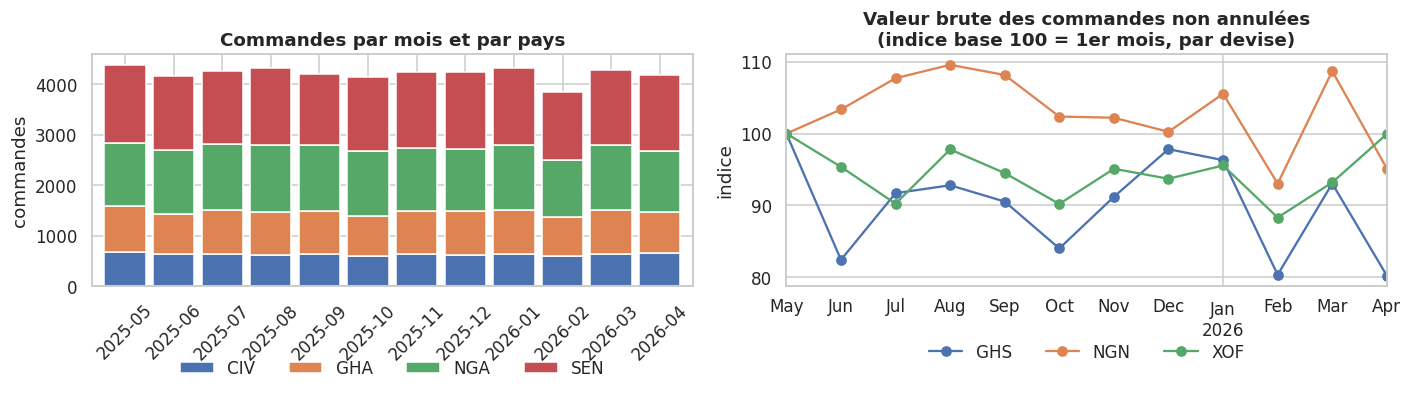

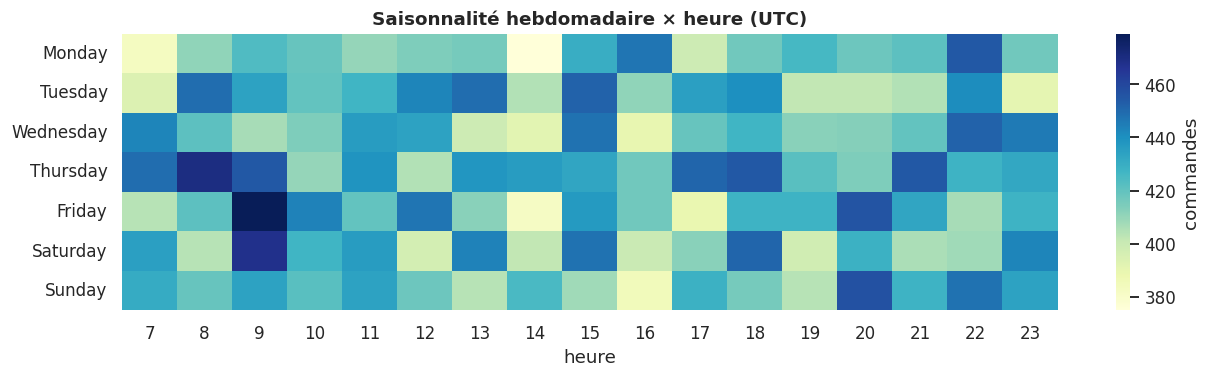

In [21]:
o = orders_u.copy()
o["month"] = o["order_date"].dt.to_period("M").dt.to_timestamp()
o["is_cancelled"] = o["order_status"].eq("CANCELLED")

m_country = o.groupby(["month", "country_code"]).size().unstack(fill_value=0)
m_country.index = m_country.index.strftime("%Y-%m")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
m_country.plot(kind="bar", stacked=True, ax=ax[0], width=0.85)
ax[0].tick_params(axis="x", rotation=45)
ax[0].set(title="Commandes par mois et par pays", xlabel="", ylabel="commandes")
ax[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)

cur = (o[~o["is_cancelled"]].groupby(["month", "currency"])["total_amount"].sum().unstack())
(cur / cur.iloc[0] * 100).plot(ax=ax[1], marker="o")
ax[1].set(title="Valeur brute des commandes non annulées\n(indice base 100 = 1er mois, par devise)", xlabel="", ylabel="indice")
ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
savefig("eda_dynamique_mensuelle")

o["dow"] = o["order_date"].dt.day_name()
o["hour"] = o["order_date"].dt.hour
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hm = o.pivot_table(index="dow", columns="hour", values="order_id", aggfunc="count").reindex(dow_order)
fig, ax = plt.subplots(figsize=(12, 3.6))
sns.heatmap(hm, cmap="YlGnBu", ax=ax, cbar_kws={"label": "commandes"})
ax.set(title="Saisonnalité hebdomadaire × heure (UTC)", xlabel="heure", ylabel="")
savefig("eda_saisonnalite_heure")

### 7.2 Structure des commandes : statut, canal, pays, zone

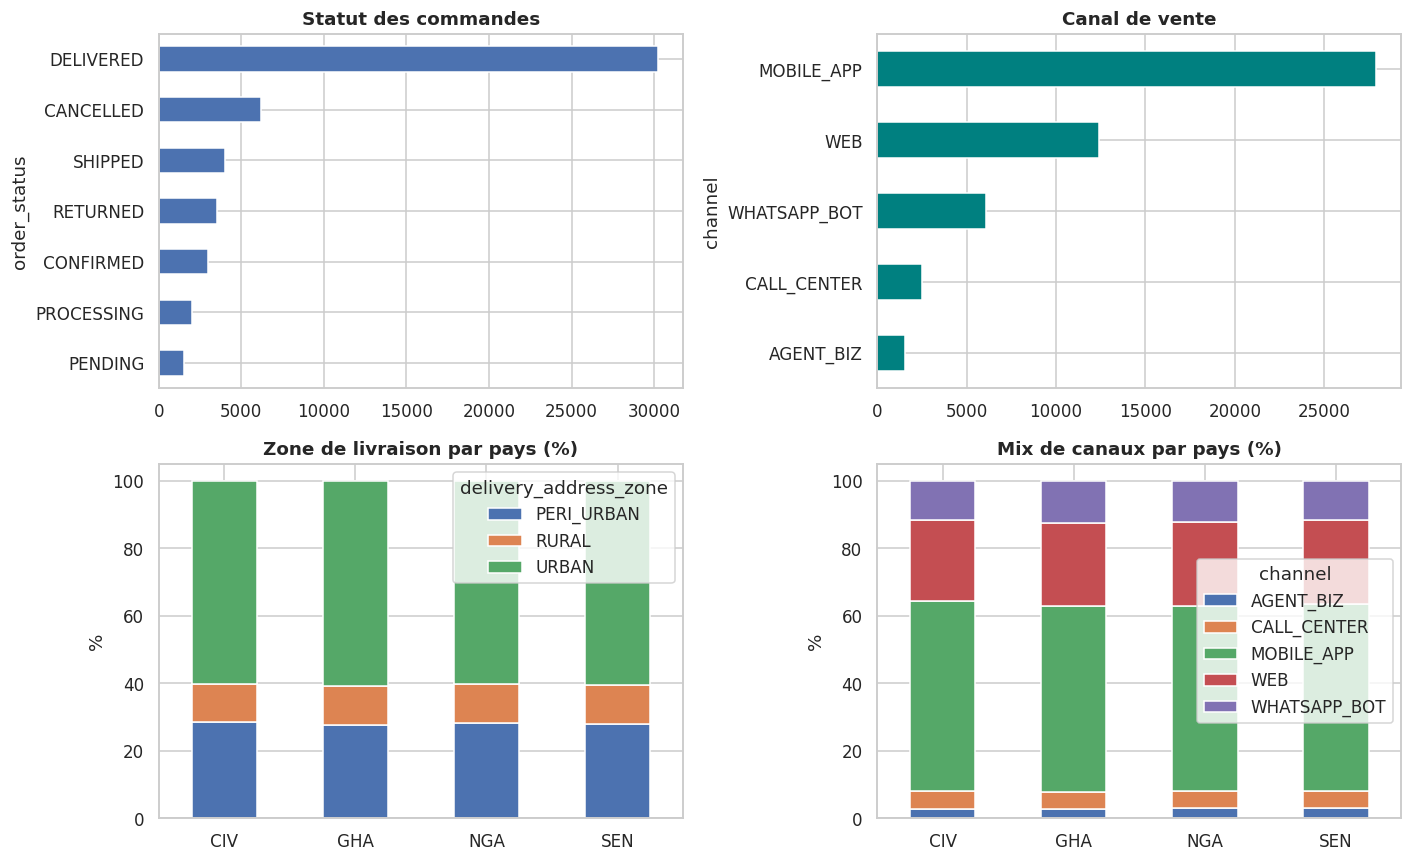

**Valeur des commandes (devise locale) — quantiles**

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
currency,,,,,,,,,,,
GHS,"10,084.00","116,276.45","94,425.76",672.62,"13,478.11","45,529.85","90,068.73","163,830.97","300,276.72","426,580.28","676,827.02"
NGN,"15,157.00","116,209.54","94,199.67","1,162.86","13,301.57","45,642.18","89,801.44","162,893.93","305,004.38","421,222.35","758,630.06"
XOF,"25,259.00","117,112.95","95,919.66",107.41,"12,982.46","46,058.15","89,758.79","162,520.55","310,623.56","433,274.04","748,740.68"


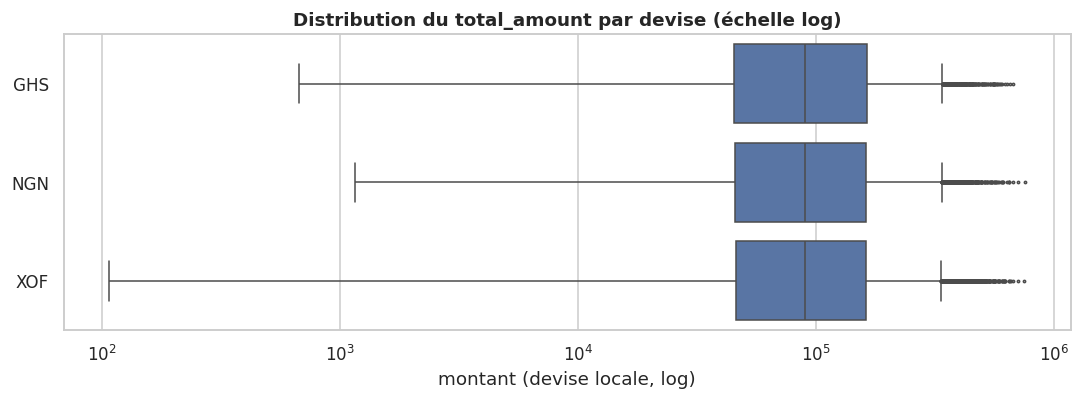

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
o["order_status"].value_counts().plot(kind="barh", ax=ax[0, 0]); ax[0, 0].set(title="Statut des commandes"); ax[0, 0].invert_yaxis()
o["channel"].value_counts().plot(kind="barh", ax=ax[0, 1], color="teal"); ax[0, 1].set(title="Canal de vente"); ax[0, 1].invert_yaxis()
(pd.crosstab(o["country_code"], o["delivery_address_zone"], normalize="index") * 100).plot(kind="bar", stacked=True, ax=ax[1, 0])
ax[1, 0].set(title="Zone de livraison par pays (%)", xlabel="", ylabel="%"); ax[1, 0].tick_params(axis="x", rotation=0)
(pd.crosstab(o["country_code"], o["channel"], normalize="index") * 100).plot(kind="bar", stacked=True, ax=ax[1, 1])
ax[1, 1].set(title="Mix de canaux par pays (%)", xlabel="", ylabel="%"); ax[1, 1].tick_params(axis="x", rotation=0)
savefig("eda_structure_commandes")

display(Markdown("**Valeur des commandes (devise locale) — quantiles**"))
display(o.groupby("currency")["total_amount"].describe(percentiles=[.05, .25, .5, .75, .95, .99]))
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.boxplot(data=o, x="total_amount", y="currency", orient="h", showfliers=True, fliersize=1.5, ax=ax)
ax.set_xscale("log"); ax.set(title="Distribution du total_amount par devise (échelle log)", xlabel="montant (devise locale, log)", ylabel="")
savefig("eda_montants_par_devise")

### 7.3 Panier et catalogue

,count,mean,std,min,50%,90%,99%,max
n_lines,"50,000.00",2.15,1.19,1.00,2.00,4.00,5.00,7.00
units,"50,000.00",3.42,2.29,1.00,3.00,7.00,10.00,16.00


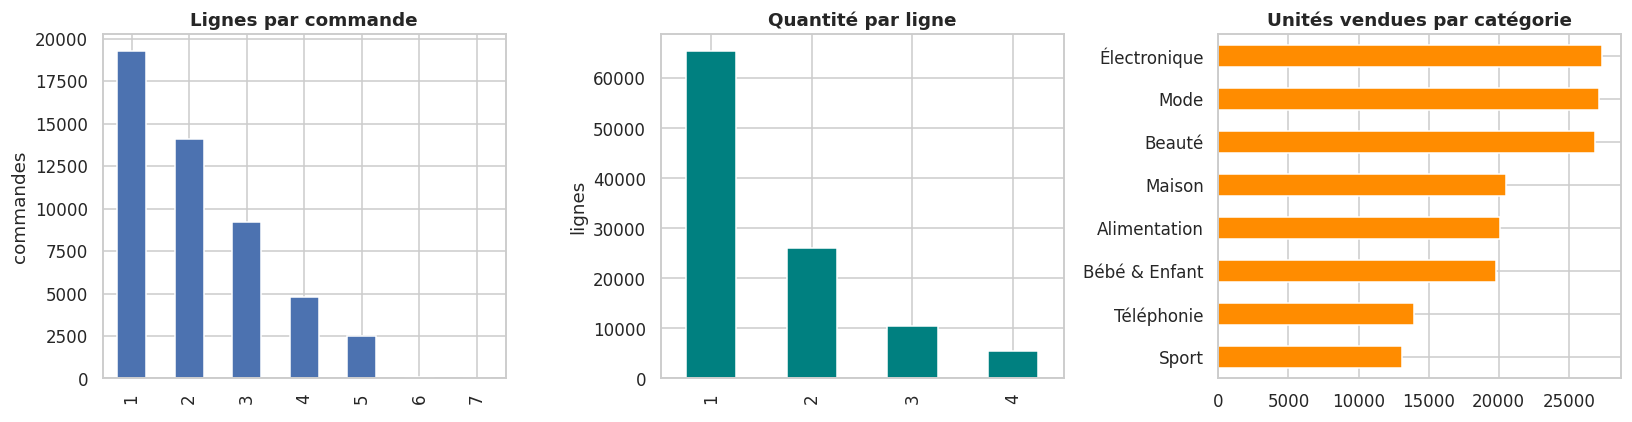

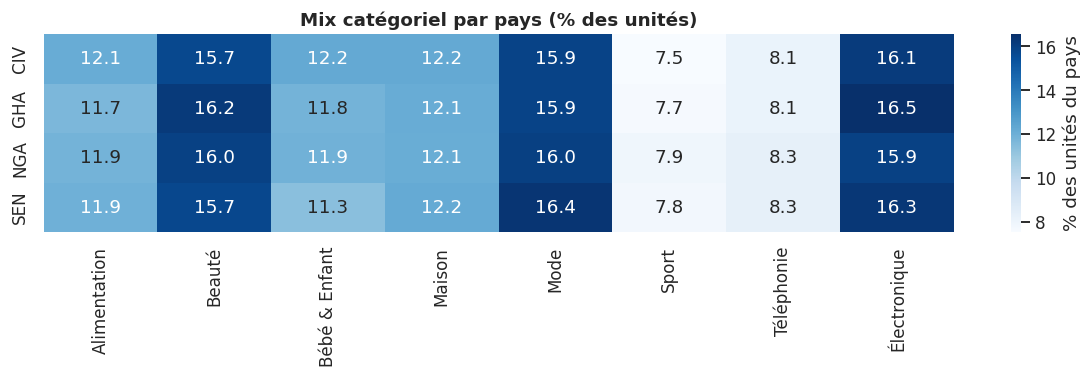

Vendeurs actifs (lignes) : 5,237 · les 10 % de vendeurs les plus actifs portent 28.9 % des lignes
Marques distinctes : 21 · marque nulle : 0.0 % des produits
Produits jamais commandés : 2,528 (21.1 %)


In [23]:
lv = lines.loc[~orphan_line].merge(products[["product_id", "category_name", "subcategory_name", "brand", "is_perishable"]], on="product_id", how="left")
lv = lv.merge(orders_u[["order_id", "country_code", "currency"]], on="order_id", how="left")

basket = lines.groupby("order_id").agg(n_lines=("order_line_id", "count"), units=("quantity", "sum"))
display(basket.describe(percentiles=[.5, .9, .99]).T)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
basket["n_lines"].value_counts().sort_index().plot(kind="bar", ax=ax[0]); ax[0].set(title="Lignes par commande", xlabel="", ylabel="commandes")
lines["quantity"].value_counts().sort_index().plot(kind="bar", ax=ax[1], color="teal"); ax[1].set(title="Quantité par ligne", xlabel="", ylabel="lignes")
lv.groupby("category_name")["quantity"].sum().sort_values().plot(kind="barh", ax=ax[2], color="darkorange"); ax[2].set(title="Unités vendues par catégorie", ylabel="")
savefig("eda_panier_catalogue")

share = pd.crosstab(lv["country_code"], lv["category_name"], values=lv["quantity"], aggfunc="sum", normalize="index") * 100
fig, ax = plt.subplots(figsize=(11, 3.6))
sns.heatmap(share, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={"label": "% des unités du pays"})
ax.set(title="Mix catégoriel par pays (% des unités)", xlabel="", ylabel="")
savefig("eda_mix_categories_pays")

seller_lines = lines.groupby("seller_id").size().sort_values(ascending=False)
cum = seller_lines.cumsum() / seller_lines.sum()
top10 = seller_lines.head(max(1, int(0.1 * len(seller_lines)))).sum() / seller_lines.sum()
print(f"Vendeurs actifs (lignes) : {len(seller_lines):,} · les 10 % de vendeurs les plus actifs portent {100*top10:.1f} % des lignes")
print(f"Marques distinctes : {products['brand'].nunique():,} · marque nulle : {100*products['brand'].isna().mean():.1f} % des produits")
print(f"Produits jamais commandés : {int((~products['product_id'].isin(lines['product_id'])).sum()):,} ({100*(~products['product_id'].isin(lines['product_id'])).mean():.1f} %)")

### 7.4 Paiements

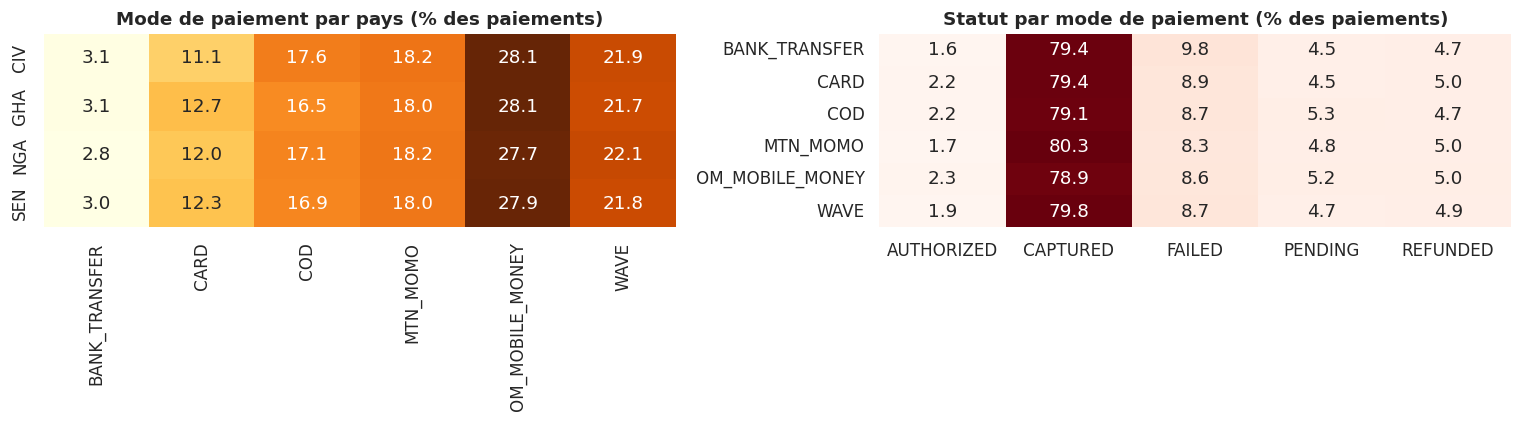

Taux d'échec (FAILED) par PSP :


,failed_%
payment_provider,
CinetPay,9.75
Flutterwave,8.33
Internal,8.69
PayDunya,8.62
Paystack,8.94
Wave Direct,8.74


In [24]:
pp = payments.merge(orders_u[["order_id", "country_code"]], on="order_id", how="left")
mix = pd.crosstab(pp["country_code"], pp["payment_method"], normalize="index") * 100
st = pd.crosstab(pp["payment_method"], pp["payment_status"], normalize="index") * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(mix, annot=True, fmt=".1f", cmap="YlOrBr", ax=ax[0], cbar=False); ax[0].set(title="Mode de paiement par pays (% des paiements)", xlabel="", ylabel="")
sns.heatmap(st, annot=True, fmt=".1f", cmap="Reds", ax=ax[1], cbar=False); ax[1].set(title="Statut par mode de paiement (% des paiements)", xlabel="", ylabel="")
savefig("eda_paiements")
print("Taux d'échec (FAILED) par PSP :")
display((payments.groupby("payment_provider")["payment_status"].apply(lambda s: 100 * (s == "FAILED").mean())).round(2).rename("failed_%").to_frame())

### 7.5 Logistique

,livraisons,failed_pct,returned_wh_pct,cout_moyen,tentatives_moy,delai_median_j,tardives_pct
carrier,,,,,,,
YANGO_DELIVERY,5227,5.41,6.43,"3,115.69",1.32,4.00,5.13
BOLT_DELIVERY,5199,5.02,6.00,"3,159.98",1.32,4.00,5.26
GLOVO,5176,4.71,5.76,"3,165.01",1.32,4.00,4.78
CHRONOPOST_AFRIQUE,5168,4.90,5.75,"3,148.34",1.31,4.00,5.61
DHL,5162,5.48,6.35,"3,160.22",1.31,4.00,4.61
INTERNAL_FLEET,5138,4.81,5.90,"3,142.71",1.33,4.00,4.16
AFRIPOST,5124,4.90,5.93,"3,178.94",1.33,4.00,4.93
JUMIA_LOGISTICS,5024,5.00,6.41,"3,132.12",1.31,4.00,4.74


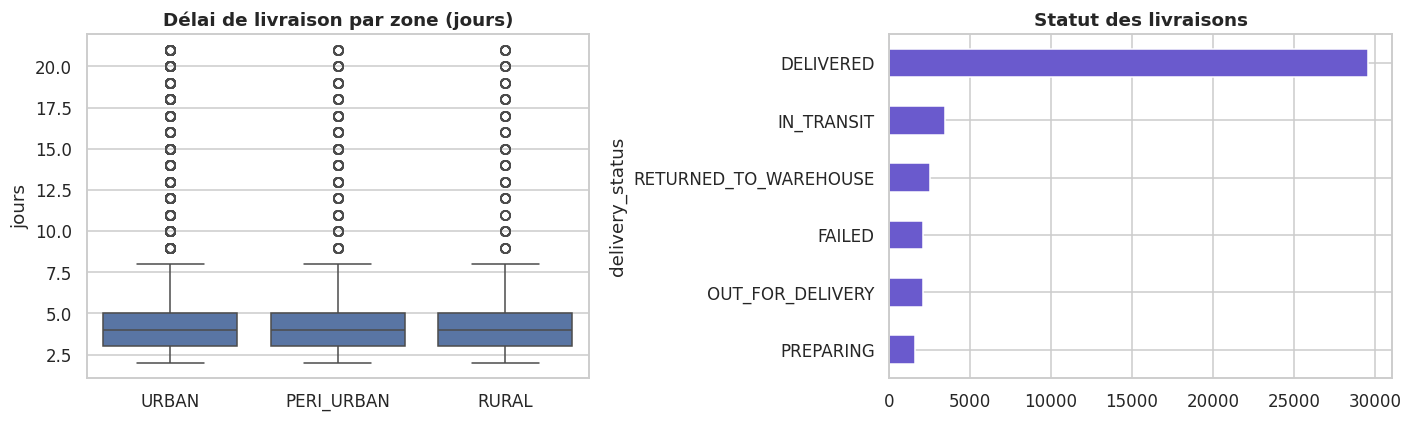

,count,mean,std,min,50%,95%,max
delivery_address_zone,,,,,,,
PERI_URBAN,"8,271.00",4.43,2.61,2.00,4.00,6.00,21.00
RURAL,"3,438.00",4.46,2.79,2.00,4.00,6.00,21.00
URBAN,"17,858.00",4.51,2.76,2.00,4.00,6.00,21.00


In [25]:
d_ok = dl[dl["days_order_to_delivery"].notna()]
carr = deliveries.groupby("carrier").agg(
    livraisons=("delivery_id", "count"),
    failed_pct=("delivery_status", lambda s: 100 * (s == "FAILED").mean()),
    returned_wh_pct=("delivery_status", lambda s: 100 * (s == "RETURNED_TO_WAREHOUSE").mean()),
    cout_moyen=("delivery_cost", "mean"),
    tentatives_moy=("delivery_attempts", "mean"),
)
carr["delai_median_j"] = d_ok.groupby("carrier")["days_order_to_delivery"].median()
carr["tardives_pct"] = d_ok.groupby("carrier")["days_order_to_delivery"].apply(lambda s: 100 * (s >= 7).mean())
display(carr.sort_values("livraisons", ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=d_ok, x="delivery_address_zone", y="days_order_to_delivery", order=["URBAN", "PERI_URBAN", "RURAL"], ax=ax[0])
ax[0].set(title="Délai de livraison par zone (jours)", xlabel="", ylabel="jours")
deliveries["delivery_status"].value_counts().plot(kind="barh", ax=ax[1], color="slateblue"); ax[1].invert_yaxis(); ax[1].set(title="Statut des livraisons")
savefig("eda_logistique")
display(d_ok.groupby("delivery_address_zone")["days_order_to_delivery"].describe(percentiles=[.5, .95]))

### 7.6 Clients

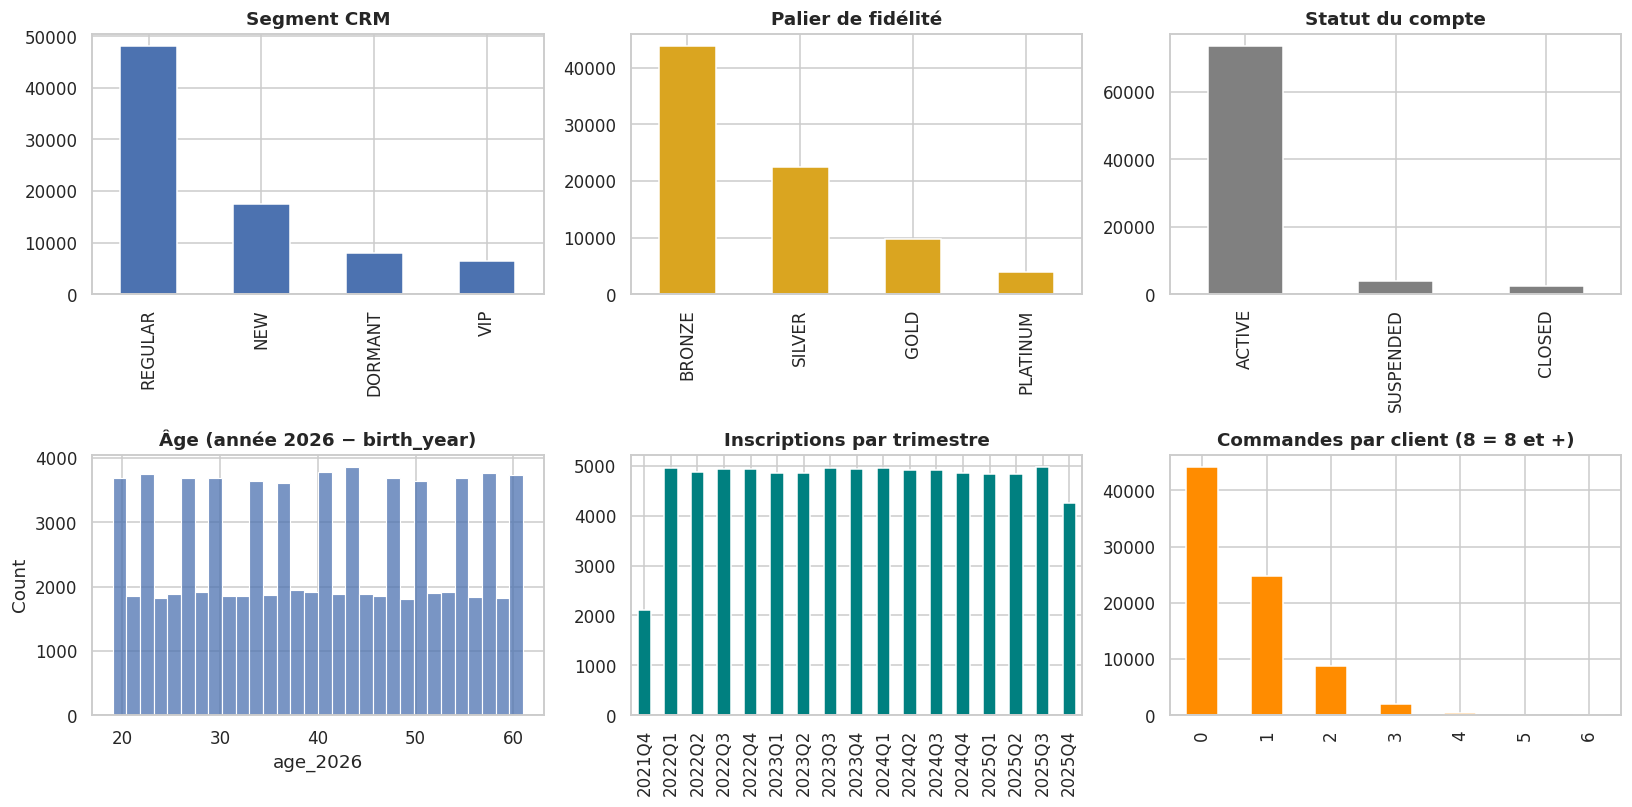

Cohérence segment CRM ↔ activité réelle (commandes par client, médiane) :


,count,median,mean,max
customer_segment,,,,
DORMANT,7966,0.00,0.62,5
NEW,17558,0.00,0.63,6
REGULAR,48083,0.00,0.62,6
VIP,6393,0.00,0.63,5


Cohérence palier de fidélité ↔ activité réelle :


,count,median,mean,max
loyalty_tier,,,,
BRONZE,43830,0.00,0.62,6
GOLD,9683,0.00,0.63,6
PLATINUM,3997,0.00,0.63,5
SILVER,22490,0.00,0.63,6


Clients (dédupliqués) n'ayant jamais commandé : 44,174 (55.2 %)


In [26]:
cu = customers.drop_duplicates("email_hash").copy()
cu["age_2026"] = 2026 - cu["birth_year"]
orders_per_customer = orders_u.groupby("customer_id").size().reindex(cu["customer_id"]).fillna(0).astype(int)

fig, ax = plt.subplots(2, 3, figsize=(15, 7.5))
cu["customer_segment"].value_counts().plot(kind="bar", ax=ax[0, 0]); ax[0, 0].set(title="Segment CRM", xlabel="")
cu["loyalty_tier"].value_counts().reindex(["BRONZE", "SILVER", "GOLD", "PLATINUM"]).plot(kind="bar", ax=ax[0, 1], color="goldenrod"); ax[0, 1].set(title="Palier de fidélité", xlabel="")
cu["account_status"].value_counts().plot(kind="bar", ax=ax[0, 2], color="grey"); ax[0, 2].set(title="Statut du compte", xlabel="")
sns.histplot(cu["age_2026"], bins=30, ax=ax[1, 0]); ax[1, 0].set(title="Âge (année 2026 − birth_year)")
cu["registration_date"].dt.to_period("Q").astype(str).value_counts().sort_index().plot(kind="bar", ax=ax[1, 1], color="teal"); ax[1, 1].set(title="Inscriptions par trimestre", xlabel="")
orders_per_customer.clip(upper=8).value_counts().sort_index().plot(kind="bar", ax=ax[1, 2], color="darkorange"); ax[1, 2].set(title="Commandes par client (8 = 8 et +)", xlabel="")
savefig("eda_clients")

print("Cohérence segment CRM ↔ activité réelle (commandes par client, médiane) :")
display(cu.assign(n_orders=orders_per_customer.values).groupby("customer_segment")["n_orders"].agg(["count", "median", "mean", "max"]))
print("Cohérence palier de fidélité ↔ activité réelle :")
display(cu.assign(n_orders=orders_per_customer.values).groupby("loyalty_tier")["n_orders"].agg(["count", "median", "mean", "max"]))
print(f"Clients (dédupliqués) n'ayant jamais commandé : {int((orders_per_customer == 0).sum()):,} ({100*(orders_per_customer == 0).mean():.1f} %)")

**Lecture.** Si les moyennes et médianes de commandes par client sont quasi identiques d'un segment / palier à l'autre, alors `customer_segment` et `loyalty_tier` (calculés « en amont par le CRM ») **ne reflètent pas l'activité transactionnelle observée** : le RFM doit être recalculé à partir des commandes en curated, et ces deux attributs traités comme des descripteurs déclaratifs, pas comme des mesures.

--------------------------------------------------------------------------------------------------
## End 

-------------------------------------------------------------------------------------------------
## 8. Biais et limites du dataset

Le sujet (§18) impose de documenter explicitement les biais potentiels et leurs implications. Les indicateurs ci-dessous fournissent les chiffres ; l'interprétation doit être reprise dans la documentation du dépôt.

In [27]:
bias = pd.DataFrame({
    "commandes_%": 100 * o["country_code"].value_counts(normalize=True),
    "zone_urbaine_%": 100 * o.groupby("country_code")["delivery_address_zone"].apply(lambda s: (s == "URBAN").mean()),
    "zone_rurale_%": 100 * o.groupby("country_code")["delivery_address_zone"].apply(lambda s: (s == "RURAL").mean()),
    "canal_mobile_app_%": 100 * o.groupby("country_code")["channel"].apply(lambda s: (s == "MOBILE_APP").mean()),
    "panier_median_(devise locale)": o.groupby("country_code")["total_amount"].median(),
    "devise": o.groupby("country_code")["currency"].first(),
})
display(bias.sort_values("commandes_%", ascending=False))

print(f"Part globale zone urbaine : {100*(o['delivery_address_zone']=='URBAN').mean():.1f} % · rurale : {100*(o['delivery_address_zone']=='RURAL').mean():.1f} %")
minors = int((age_reg < 18).sum())
print(f"Clients dont l'âge à l'inscription est < 18 ans : {minors:,} ({100*minors/len(customers):.2f} %)")

,commandes_%,zone_urbaine_%,zone_rurale_%,canal_mobile_app_%,panier_median_(devise locale),devise
country_code,,,,,,
SEN,35.02,60.35,11.67,55.32,"90,052.89",XOF
NGA,30.01,60.19,11.67,54.86,"89,801.44",NGN
GHA,19.97,60.71,11.75,55.11,"90,068.73",GHS
CIV,14.99,60.20,11.33,56.26,"89,317.43",XOF


Part globale zone urbaine : 60.4 % · rurale : 11.6 %
Clients dont l'âge à l'inscription est < 18 ans : 2,977 (3.67 %)


## 9. Synthèse, règles de traitement proposées et exports

### 9.1 Registre des anomalies

In [28]:
sev_order = {"Haute": 0, "Moyenne": 1, "Info": 2}
anomalies_df = (pd.DataFrame(ANOMALIES)
                .assign(_s=lambda d: d["severity"].map(sev_order))
                .sort_values(["_s", "code"]).drop(columns="_s").reset_index(drop=True))
display(anomalies_df[["code", "table", "description", "observed", "base", "observed_%", "brief_expected", "severity"]])

,code,table,description,observed,base,observed_%,brief_expected,severity
0,A1,orders,order_id dupliqué (doublon technique),1500,52000,2.88,~3 % (~1 500),Haute
1,A2,order_lines,product_id absent de products (intégrité référ...,2108,107517,1.96,~2 % (~2 100),Haute
2,A2b,order_lines,line_total ≠ quantity × unit_price − line_disc...,2108,107517,1.96,non documenté,Haute
3,A3,orders,total_amount ≠ subtotal + shipping − discount,500,50500,0.99,~1 % (~500),Haute
4,A3b,orders,commande sans aucune ligne de détail,500,50500,0.99,non documenté,Haute
5,A4c,payments,sur-encaissement / double capture (Σ CAPTURED ...,98,36559,0.27,non documenté,Haute
6,A7a,customers,email_hash dupliqué (compte créé en double),1200,81200,1.48,~1 200,Haute
7,A7b,customers,customer_id dupliqué avec profils différents (...,10,81200,0.01,non documenté,Haute
8,A3c,orders,subtotal ≠ Σ line_total (impact des lignes orp...,2070,50500,4.10,non documenté,Moyenne
9,A4a,payments,retry FAILED → CAPTURED (commande à ≥ 1 échec ...,390,36559,1.07,~500 commandes,Moyenne


### 9.2 Règles de traitement proposées pour la zone *curated*

In [29]:
with pd.option_context("display.max_colwidth", None):
    display(anomalies_df[["code", "description", "treatment"]])

,code,description,treatment
0,A1,order_id dupliqué (doublon technique),Dédup sur order_id (garder updated_at max) ; conserver l'écart en table d'audit
1,A2,product_id absent de products (intégrité référentielle),Quarantaine des lignes orphelines ; exclure de FACT_ORDER_LINE ; alerte si taux > seuil
2,A2b,line_total ≠ quantity × unit_price − line_discount,Quarantaine (ici entièrement corrélé aux lignes orphelines) ; test dbt sur la formule
3,A3,total_amount ≠ subtotal + shipping − discount,Quarantaine ; recalcul depuis order_lines seulement si lignes disponibles
4,A3b,commande sans aucune ligne de détail,Quarantaine (commande non exploitable en FACT_ORDER_LINE)
5,A4c,sur-encaissement / double capture (Σ CAPTURED > total),Quarantaine + rapprochement PSP (transaction_reference) ; ne jamais sommer sans dédup
6,A7a,email_hash dupliqué (compte créé en double),Clé de rapprochement MDM (email_hash) → customer_master_id ; consolider RFM au niveau master
7,A7b,customer_id dupliqué avec profils différents (collision de clé),Quarantaine ; clé de substitution surrogate_key dans DIM_CUSTOMER ; alerte à l'ingestion
8,A3c,subtotal ≠ Σ line_total (impact des lignes orphelines),Réconcilier après retrait des lignes orphelines ; test dbt de réconciliation
9,A4a,retry FAILED → CAPTURED (commande à ≥ 1 échec puis capture),Dédup : 1 paiement de référence par commande (dernier CAPTURED) ; conserver l'historique en table de tentatives


### 9.3 Tableau de bord qualité (score de complétude et de validité par table)

In [30]:
score_rows = []
for t in TABLES:
    df = dfs[t]
    completeness = 100 * (1 - df.isna().to_numpy().mean())
    v = validity[validity["table"].str.startswith(t)]
    a = anomalies_df[anomalies_df["table"] == t]
    score_rows.append({
        "table": t, "rows": len(df), "completude_%": completeness,
        "controles_en_echec": int((v["violations"] > 0).sum()),
        "anomalies_enregistrees": len(a),
    })
scorecard = pd.DataFrame(score_rows).set_index("table")
display(scorecard)

# Part des lignes d'order_lines exploitables telles quelles (ni orpheline, ni total incohérent)
usable_lines = ~(orphan_line | lt_mismatch)
print(f"order_lines directement exploitables : {int(usable_lines.sum()):,} / {len(lines):,} ({100*usable_lines.mean():.2f} %)")
clean_orders = (~f_formula) & (~f_nolines)
print(f"orders (dédupliquées) exploitables sans correction : {int(clean_orders.sum()):,} / {len(chk):,} ({100*clean_orders.mean():.2f} %)")

,rows,completude_%,controles_en_echec,anomalies_enregistrees
table,,,,
orders,52000,96.56,2,4
order_lines,107517,100.00,1,2
customers,81200,100.00,4,2
products,12000,100.00,1,2
payments,46141,100.00,0,3
deliveries,41218,96.86,1,2


order_lines directement exploitables : 105,409 / 107,517 (98.04 %)
orders (dédupliquées) exploitables sans correction : 50,000 / 50,500 (99.01 %)


anomalies_registry.csv  (2.8 Ko)
column_profiles.csv  (7.1 Ko)
figures/a5_delais_livraison.png  (33.6 Ko)
figures/eda_clients.png  (95.8 Ko)
figures/eda_dynamique_mensuelle.png  (94.1 Ko)
figures/eda_logistique.png  (51.2 Ko)
figures/eda_mix_categories_pays.png  (54.3 Ko)
figures/eda_montants_par_devise.png  (21.7 Ko)
figures/eda_paiements.png  (86.5 Ko)
figures/eda_panier_catalogue.png  (59.7 Ko)
figures/eda_saisonnalite_heure.png  (35.7 Ko)
figures/eda_structure_commandes.png  (87.1 Ko)
foreign_keys.csv  (0.3 Ko)
primary_keys.csv  (0.3 Ko)
profiling_summary.json  (7.4 Ko)
validity_checks.csv  (2.9 Ko)
